In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

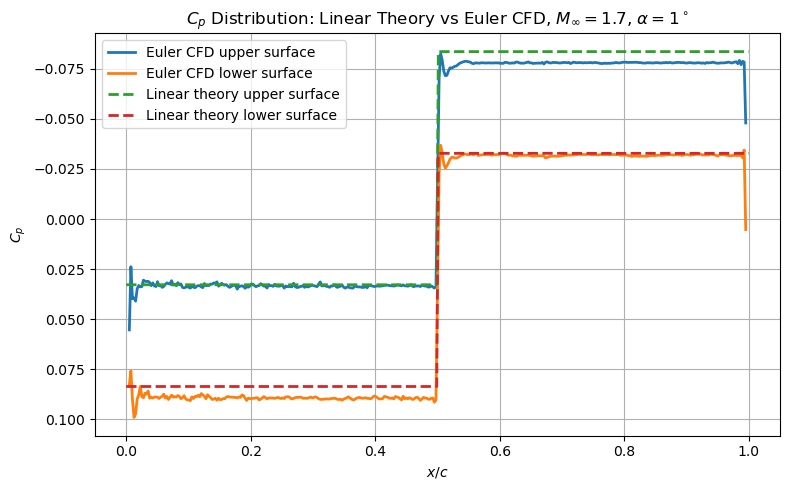

In [3]:
# -----------------------------
# constants
# -----------------------------
M_inf = 1.7
alpha_deg = 1.0
alpha = np.deg2rad(alpha_deg)
beta = np.sqrt(M_inf**2 - 1.0)

# -----------------------------
# load CFD Cp data
# -----------------------------
file = Path("Data") / "a=1-Cp.csv"
df = pd.read_csv(file)

# clean column names
df.columns = [c.strip().strip('"') for c in df.columns]

# clip out first few bad rows
df = df.iloc[4:].copy()

# extract data
x_c = df["Points:0"].to_numpy()
y   = df["Points:1"].to_numpy()
Cp  = df["Pressure_Coefficient"].to_numpy()

# -----------------------------
# split upper/lower surfaces
# -----------------------------
upper = y >= 0
lower = y < 0
chord = (x_c > 0.005) & (x_c < 0.995)

x_u, Cp_u = x_c[upper & chord], Cp[upper & chord]
x_l, Cp_l = x_c[lower & chord], Cp[lower & chord]

# sort for plotting
idx_u = np.argsort(x_u)
idx_l = np.argsort(x_l)

x_u, Cp_u = x_u[idx_u], Cp_u[idx_u]
x_l, Cp_l = x_l[idx_l], Cp_l[idx_l]

# -----------------------------
# linear theory Cp for diamond airfoil
# -----------------------------
x_front = np.linspace(0.0, 0.5, 200)
x_back  = np.linspace(0.5, 1.0, 200, endpoint=True)

Cp_u_front = np.full_like(x_front, 2.0 * (0.04 - alpha) / beta)
Cp_u_back  = np.full_like(x_back,  2.0 * (-0.04 - alpha) / beta)
Cp_l_front = np.full_like(x_front, 2.0 * (0.04 + alpha) / beta)
Cp_l_back  = np.full_like(x_back,  2.0 * (-0.04 + alpha) / beta)

Cp_upper_lin = np.concatenate((Cp_u_front, Cp_u_back))
Cp_lower_lin = np.concatenate((Cp_l_front, Cp_l_back))

x_all = np.linspace(0.0, 1.0, 400, endpoint=True)

# -----------------------------
# make output folder
# -----------------------------
output_dir = Path("Outputs")
output_dir.mkdir(exist_ok=True)

# -----------------------------
# plot
# -----------------------------
plt.figure(figsize=(8, 5))

# Euler CFD
plt.plot(x_u, Cp_u, linewidth=2, label="Euler CFD upper surface")
plt.plot(x_l, Cp_l, linewidth=2, label="Euler CFD lower surface")

# Linear theory dotted
plt.plot(x_all, Cp_upper_lin, "--", linewidth=2,
         label="Linear theory upper surface")
plt.plot(x_all, Cp_lower_lin, "--", linewidth=2,
         label="Linear theory lower surface")

plt.xlabel(r"$x/c$")
plt.ylabel(r"$C_p$")
plt.title(r"$C_p$ Distribution: Linear Theory vs Euler CFD, $M_\infty=1.7$, $\alpha=1^\circ$")
plt.grid(True)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()

# save as PDF
plt.savefig(output_dir / "cp_linear_vs_euler.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [4]:
# -----------------------------
# constants for this lab
# -----------------------------
M_inf = 1.7
alpha_deg = 1.0
alpha = np.deg2rad(alpha_deg)

# base folder containing:
# a=0, a=1, a=2, a=4, a=6, a=8, a=10, RANS
base = Path("./CFD")

# -----------------------------
# linear theory for diamond airfoil
# -----------------------------
# from the lab:
# Cp = 2*theta/sqrt(M_inf^2 - 1)
# Cl = 4*alpha/sqrt(M_inf^2 - 1)
# Cd = 4*alpha^2/sqrt(M_inf^2 - 1) + 2/sqrt(M_inf^2 - 1) * (sigma_u^2 + sigma_l^2)

beta = np.sqrt(M_inf**2 - 1.0)

# diamond airfoil with t/c = 0.04
# upper surface slope:
# dy_u/d(x/c) = +0.04 for 0 <= x/c < 0.5
# dy_u/d(x/c) = -0.04 for 0.5 <= x/c <= 1
#
# lower surface slope:
# dy_l/d(x/c) = -0.04 for 0 <= x/c < 0.5
# dy_l/d(x/c) = +0.04 for 0.5 <= x/c <= 1

m1 = 0.04
m2 = -0.04

# theta definitions from lab
theta_u_front = m1 - alpha
theta_u_back  = m2 - alpha
theta_l_front = -(-0.04) + alpha   # -dy_l/dx + alpha
theta_l_back  = -(+0.04) + alpha

Cp_u_front = 2.0 * theta_u_front / beta
Cp_u_back  = 2.0 * theta_u_back  / beta
Cp_l_front = 2.0 * theta_l_front / beta
Cp_l_back  = 2.0 * theta_l_back  / beta

# sigma integrals
# sigma_u^2 = integral_0^1 (dy_u/d(x/c))^2 d(x/c)
# sigma_l^2 = integral_0^1 (dy_l/d(x/c))^2 d(x/c)
# since slope magnitude is 0.04 everywhere on each surface:
sigma_u_sq = 0.04**2
sigma_l_sq = 0.04**2

Cl_linear = 4.0 * alpha / beta
Cd_linear = 4.0 * alpha**2 / beta + (2.0 / beta) * (sigma_u_sq + sigma_l_sq)

print(f"Linear theory:")
print(f"  Cl = {Cl_linear:.6f}")
print(f"  Cd = {Cd_linear:.6f}")

# -----------------------------
# read Euler CFD Cl and Cd from history.csv
# use the alpha = 1 deg folder
# -----------------------------
hist_file = base / "a=1" / "history.csv"
hist = pd.read_csv(hist_file)

# clean column names just in case SU2 kept extra spaces/quotes
hist.columns = [c.strip().strip('"') for c in hist.columns]

Cl_cfd = hist["CL"].iloc[-1]
Cd_cfd = hist["CD"].iloc[-1]

print("\nEuler CFD (from history.csv, final iteration):")
print(f"  Cl = {Cl_cfd:.6f}")
print(f"  Cd = {Cd_cfd:.6f}")

# comparison table
comparison = pd.DataFrame({
    "Method": ["Linear theory", "Euler CFD"],
    "Cl": [Cl_linear, Cl_cfd],
    "Cd": [Cd_linear, Cd_cfd]
})

print("\nComparison:")
print(comparison.to_string(index=False))

Linear theory:
  Cl = 0.050782
  Cd = 0.005542

Euler CFD (from history.csv, final iteration):
  Cl = 0.050655
  Cd = 0.005488

Comparison:
       Method       Cl       Cd
Linear theory 0.050782 0.005542
    Euler CFD 0.050655 0.005488


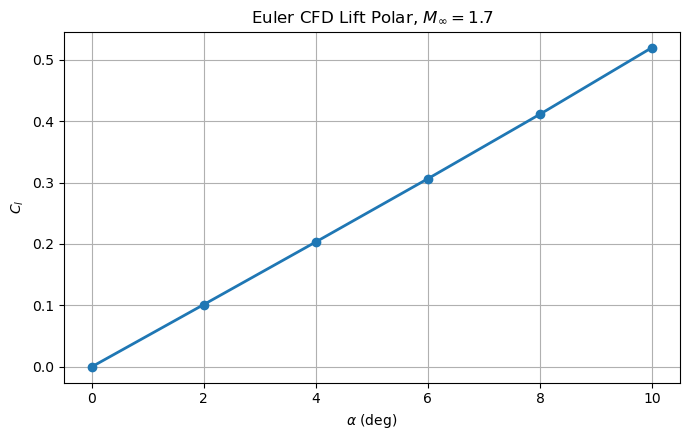

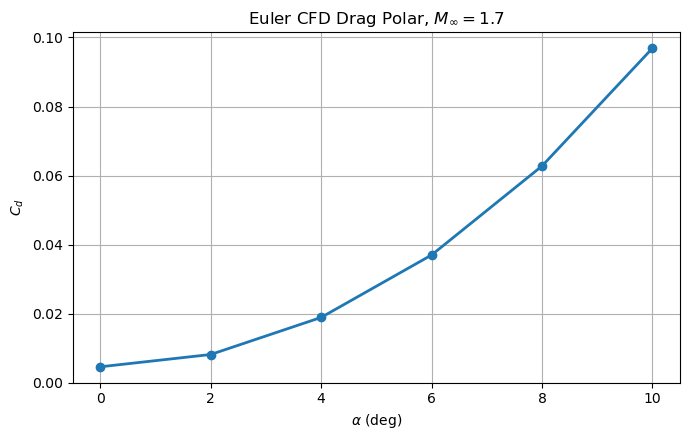

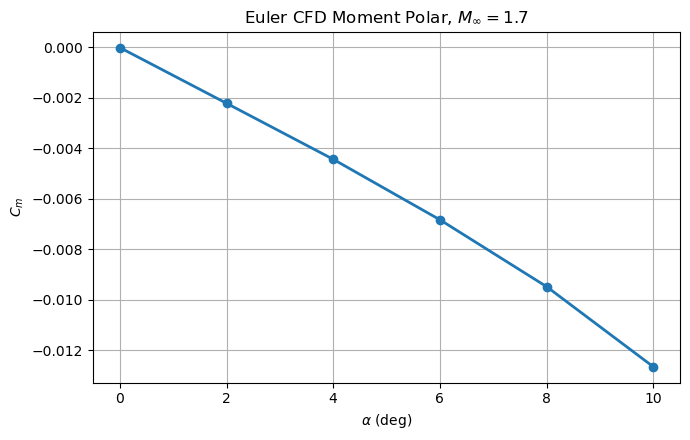

Final CFD coefficients:
alpha =  0 deg : CL = -0.000002, CD = 0.004598, CM = -0.000011
alpha =  2 deg : CL = 0.101388, CD = 0.008160, CM = -0.002219
alpha =  4 deg : CL = 0.203350, CD = 0.018898, CM = -0.004439
alpha =  6 deg : CL = 0.306301, CD = 0.036978, CM = -0.006836
alpha =  8 deg : CL = 0.411265, CD = 0.062756, CM = -0.009486
alpha = 10 deg : CL = 0.519783, CD = 0.096881, CM = -0.012661

Lift-curve slope results:
Euler CFD Cla = 2.972427 1/rad
Linear theory Cla = 2.909572 1/rad
Percent difference = 2.16%
Linear-fit intercept = -0.002379


In [5]:
# -----------------------------
# settings
# -----------------------------
base = Path("./CFD")
alphas_deg = np.array([0, 2, 4, 6, 8, 10], dtype=float)

M_inf = 1.7
beta = np.sqrt(M_inf**2 - 1.0)

# linear theory lift-curve slope
# Cl = 4*alpha / sqrt(M^2 - 1), alpha in radians
cla_linear_theory = 4.0 / beta

# -----------------------------
# make output folder
# -----------------------------
output_dir = Path("Outputs")
output_dir.mkdir(exist_ok=True)

# -----------------------------
# storage
# -----------------------------
CL = []
CD = []
CM = []

# -----------------------------
# read each history.csv
# -----------------------------
for a in alphas_deg.astype(int):
    hist_file = base / f"a={a}" / "history.csv"
    df = pd.read_csv(hist_file)

    # clean column names
    df.columns = [c.strip().strip('"') for c in df.columns]

    # use final converged values
    CL.append(df["CL"].iloc[-1])
    CD.append(df["CD"].iloc[-1])
    CM.append(df["CMz"].iloc[-1])   # using CMz from your history headers

CL = np.array(CL)
CD = np.array(CD)
CM = np.array(CM)

# -----------------------------
# plots for part 2(a)
# -----------------------------
plt.figure(figsize=(7, 4.5))
plt.plot(alphas_deg, CL, marker='o', linewidth=2)
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$C_l$')
plt.title(r'Euler CFD Lift Polar, $M_\infty = 1.7$')
plt.grid(True)
plt.tight_layout()
plt.savefig(output_dir / "cl_vs_alpha.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(alphas_deg, CD, marker='o', linewidth=2)
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$C_d$')
plt.title(r'Euler CFD Drag Polar, $M_\infty = 1.7$')
plt.grid(True)
plt.tight_layout()
plt.savefig(output_dir / "cd_vs_alpha.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(alphas_deg, CM, marker='o', linewidth=2)
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$C_m$')
plt.title(r'Euler CFD Moment Polar, $M_\infty = 1.7$')
plt.grid(True)
plt.tight_layout()
plt.savefig(output_dir / "cm_vs_alpha.pdf", format="pdf", bbox_inches="tight")
plt.show()

# -----------------------------
# part 2(b): lift-curve slope
# -----------------------------
# use the linear region; for this diamond airfoil, actually its all linear lol
linear_mask = alphas_deg <= 10

alpha_linear_deg = alphas_deg[linear_mask]
alpha_linear_rad = np.deg2rad(alpha_linear_deg)
CL_linear = CL[linear_mask]

# best-fit slope: Cl = Cla*alpha + b
cla_cfd, intercept = np.polyfit(alpha_linear_rad, CL_linear, 1)

print("Final CFD coefficients:")
for a, cl, cd, cm in zip(alphas_deg, CL, CD, CM):
    print(f"alpha = {a:>2.0f} deg : CL = {cl:.6f}, CD = {cd:.6f}, CM = {cm:.6f}")

print("\nLift-curve slope results:")
print(f"Euler CFD Cla = {cla_cfd:.6f} 1/rad")
print(f"Linear theory Cla = {cla_linear_theory:.6f} 1/rad")
print(f"Percent difference = {100*(cla_cfd - cla_linear_theory)/cla_linear_theory:.2f}%")
print(f"Linear-fit intercept = {intercept:.6f}")

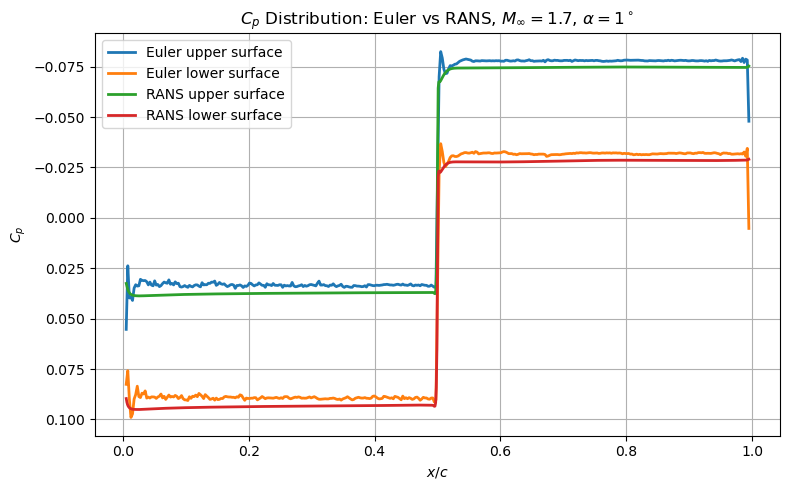

Baseline coefficient comparison:
Euler : CL = 0.050655, CD = 0.005488
RANS  : CL = 0.050975, CD = 0.009624

Percent Differences:
Delta CL = +0.630197%
Delta CD = +75.352948%


In [8]:
# get data from before
x_e_u, cp_e_u = x_u, Cp_u
x_e_l, cp_e_l = x_l, Cp_l

# -----------------------------
# make output folder
# -----------------------------
output_dir = Path("Outputs")
output_dir.mkdir(exist_ok=True)

# -----------------------------
# load Cp file
# -----------------------------
rans_cp_file = Path("Data") / "RANS-Cp.csv"
df_rans = pd.read_csv(rans_cp_file)

# clean headers
df_rans.columns = [c.strip().strip('"') for c in df_rans.columns]

# clip off first few bad rows
df_rans = df_rans.iloc[4:].copy()

# -----------------------------
# extract Cp and coordinates
# -----------------------------
x_r = df_rans["Points:0"].to_numpy()
y_r = df_rans["Points:1"].to_numpy()
cp_r = df_rans["Pressure_Coefficient"].to_numpy()

# -----------------------------
# split upper/lower surfaces
# -----------------------------
upper_r = y_r >= 0
lower_r = y_r < 0
chord_r = (x_r > 0.005) & (x_r < 0.995)

x_r_u, cp_r_u = x_r[upper_r & chord_r], cp_r[upper_r & chord_r]
x_r_l, cp_r_l = x_r[lower_r & chord_r], cp_r[lower_r & chord_r]

# sort for clean lines
idx = np.argsort(x_r_u)
x_r_u, cp_r_u = x_r_u[idx], cp_r_u[idx]

idx = np.argsort(x_r_l)
x_r_l, cp_r_l = x_r_l[idx], cp_r_l[idx]

# -----------------------------
# Cp comparison plot
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(x_e_u, cp_e_u, linewidth=2, label="Euler upper surface")
plt.plot(x_e_l, cp_e_l, linewidth=2, label="Euler lower surface")

plt.plot(x_r_u, cp_r_u, linewidth=2, label="RANS upper surface")
plt.plot(x_r_l, cp_r_l, linewidth=2, label="RANS lower surface")

plt.xlabel(r"$x/c$")
plt.ylabel(r"$C_p$")
plt.title(r"$C_p$ Distribution: Euler vs RANS, $M_\infty=1.7$, $\alpha=1^\circ$")
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / "cp_euler_vs_rans.pdf", format="pdf", bbox_inches="tight")
plt.show()

# -----------------------------
# read CL and CD from history.csv
# -----------------------------
euler_hist_file = Path("CFD") / "a=1" / "history.csv"
rans_hist_file  = Path("CFD") / "RANS" / "history.csv"   # if yours is actually CDF, change this one line

hist_e = pd.read_csv(euler_hist_file)
hist_r = pd.read_csv(rans_hist_file)

hist_e.columns = [c.strip().strip('"') for c in hist_e.columns]
hist_r.columns = [c.strip().strip('"') for c in hist_r.columns]

CL_euler = hist_e["CL"].iloc[-1]
CD_euler = hist_e["CD"].iloc[-1]

CL_rans = hist_r["CL"].iloc[-1]
CD_rans = hist_r["CD"].iloc[-1]

print("Baseline coefficient comparison:")
print(f"Euler : CL = {CL_euler:.6f}, CD = {CD_euler:.6f}")
print(f"RANS  : CL = {CL_rans:.6f}, CD = {CD_rans:.6f}")

print("\nPercent Differences:")
print(f"Delta CL = {100*(CL_rans - CL_euler)/CL_euler:+.6f}%")
print(f"Delta CD = {100*(CD_rans - CD_euler)/CD_euler:+.6f}%")